#**Simple Linear Regression**

In [311]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn.model_selection import train_test_split

In [312]:
df = pd.read_csv("smart_factory_machinery_data.csv")
df.head()

,RPM,Vibration,Pressure,Humidity,Voltage,Current,Load,Operating_Hours,Machine_Mode,Maintenance_Level,Shift_Type,Temperature,Defective
0,1660,5.17,88.80,66.87,240.90,42.59,51.93,937,High-Speed,Average,Morning,71.40,1
1,4572,0.61,32.04,83.55,216.75,45.21,31.48,9329,Standard,Poor,Evening,67.07,1
2,3892,4.68,113.85,34.72,242.87,42.05,72.09,5946,High-Speed,Average,Evening,84.69,1
3,1266,4.54,38.12,49.85,240.77,9.64,60.90,8563,Standard,Poor,Night,63.83,1
4,4244,4.53,82.28,44.90,233.87,15.24,16.97,2469,Eco,Average,Morning,60.22,1


In [313]:
RPM = np.array(df['RPM'])
RPM

array([1660, 4572, 3892, ..., 3430, 3363, 4092])

In [314]:
temp = df['Temperature']
temp

,Temperature
0,71.40
1,67.07
2,84.69
3,63.83
4,60.22
...,...
1995,56.22
1996,69.10
1997,64.03
1998,75.27


**Train Test Split**

In [315]:
x_train,x_test,y_train,y_test = train_test_split(RPM,temp,test_size=0.2)

In [316]:
reg = linear_model.LinearRegression()

In [317]:
reg.fit(x_train.reshape(-1,1),y_train)

LinearRegression()

In [319]:
y_pred = reg.predict(x_test.reshape(-1,1))
y_pred

array([63.7192976 , 68.28398763, 58.15953673, 59.46260569, 70.09248939,
       64.59590762, 72.73416554, 62.34515216, 68.61567791, 59.45865699,
       57.83179515, 63.73509237, 72.79339594, 60.60772689, 65.35405683,
       62.86243104, 70.36494926, 65.36590291, 68.9394708 , 70.98094549,
       68.75783088, 66.18328253, 56.70641741, 67.52188973, 64.22078171,
       71.0401759 , 67.51004364, 61.03023712, 60.86439198, 65.06975088,
       65.41723593, 58.7557895 , 63.94832184, 72.947395  , 64.77754754,
       66.3254355 , 56.89200602, 62.65709897, 69.83582429, 62.0608462 ,
       60.12598624, 71.15073933, 59.54947695, 67.43896716, 58.27799755,
       56.63139223, 64.83282925, 67.7272218 , 60.35106179, 60.61562427,
       67.06384125, 62.87032843, 65.42118463, 60.41818958, 65.93056613,
       62.87822582, 67.94834866, 68.38665367, 67.56927405, 64.03124441,
       57.03021031, 70.49525615, 70.67689607, 58.92558333, 61.40536303,
       63.16648047, 63.55345246, 57.85548731, 58.79132774, 72.28

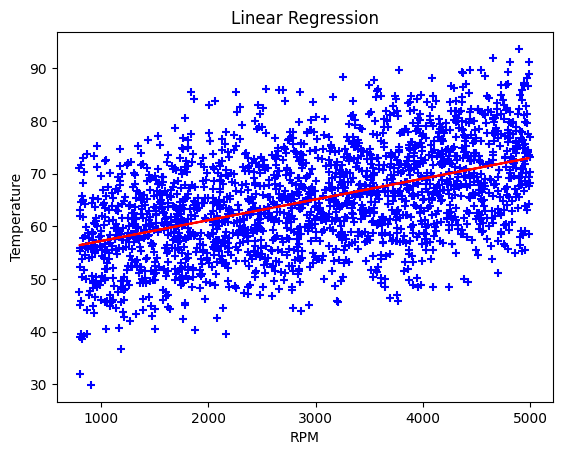

In [322]:
plt.xlabel("RPM")
plt.ylabel("Temperature")
plt.title("Linear Regression")
plt.scatter(RPM,temp,color='blue',marker='+')
plt.plot(x_test,y_pred,color='red')

In [323]:
reg.score(x_train.reshape(-1,1),y_train)

0.23887861961826518

#**Multi - Variable Linear Regression**

In [324]:
df.head()

,RPM,Vibration,Pressure,Humidity,Voltage,Current,Load,Operating_Hours,Machine_Mode,Maintenance_Level,Shift_Type,Temperature,Defective
0,1660,5.17,88.80,66.87,240.90,42.59,51.93,937,High-Speed,Average,Morning,71.40,1
1,4572,0.61,32.04,83.55,216.75,45.21,31.48,9329,Standard,Poor,Evening,67.07,1
2,3892,4.68,113.85,34.72,242.87,42.05,72.09,5946,High-Speed,Average,Evening,84.69,1
3,1266,4.54,38.12,49.85,240.77,9.64,60.90,8563,Standard,Poor,Night,63.83,1
4,4244,4.53,82.28,44.90,233.87,15.24,16.97,2469,Eco,Average,Morning,60.22,1


In [325]:
subdf = df[['RPM','Vibration','Pressure','Humidity','Voltage','Current','Load','Operating_Hours','Machine_Mode','Maintenance_Level','Shift_Type']]
subdf.head()

,RPM,Vibration,Pressure,Humidity,Voltage,Current,Load,Operating_Hours,Machine_Mode,Maintenance_Level,Shift_Type
0,1660,5.17,88.80,66.87,240.90,42.59,51.93,937,High-Speed,Average,Morning
1,4572,0.61,32.04,83.55,216.75,45.21,31.48,9329,Standard,Poor,Evening
2,3892,4.68,113.85,34.72,242.87,42.05,72.09,5946,High-Speed,Average,Evening
3,1266,4.54,38.12,49.85,240.77,9.64,60.90,8563,Standard,Poor,Night
4,4244,4.53,82.28,44.90,233.87,15.24,16.97,2469,Eco,Average,Morning


In [326]:
y = df['Temperature']
y.head()

,Temperature
0,71.40
1,67.07
2,84.69
3,63.83
4,60.22


**OneHotEncoder**

In [330]:
machine_mode_dummies = pd.get_dummies(subdf["Machine_Mode"],prefix='Machine_Mode')
machine_mode_dummies.head()

,Machine_Mode_Eco,Machine_Mode_High-Speed,Machine_Mode_Standard
0,False,True,False
1,False,False,True
2,False,True,False
3,False,False,True
4,True,False,False


In [331]:
Maintenance_dummies = pd.get_dummies(df['Maintenance_Level'],prefix='Maintenance_Level')
Maintenance_dummies.head()

,Maintenance_Level_Average,Maintenance_Level_Good,Maintenance_Level_Poor
0,True,False,False
1,False,False,True
2,True,False,False
3,False,False,True
4,True,False,False


In [333]:
shift_dummies = pd.get_dummies(df['Shift_Type'],prefix='Shift_Type')
shift_dummies.head()

,Shift_Type_Evening,Shift_Type_Morning,Shift_Type_Night
0,False,True,False
1,True,False,False
2,True,False,False
3,False,False,True
4,False,True,False


In [334]:
merged = pd.concat([subdf,machine_mode_dummies,Maintenance_dummies,shift_dummies],axis='columns')
merged.head()

,RPM,Vibration,Pressure,Humidity,Voltage,Current,Load,Operating_Hours,Machine_Mode,Maintenance_Level,Shift_Type,Machine_Mode_Eco,Machine_Mode_High-Speed,Machine_Mode_Standard,Maintenance_Level_Average,Maintenance_Level_Good,Maintenance_Level_Poor,Shift_Type_Evening,Shift_Type_Morning,Shift_Type_Night
0,1660,5.17,88.80,66.87,240.90,42.59,51.93,937,High-Speed,Average,Morning,False,True,False,True,False,False,False,True,False
1,4572,0.61,32.04,83.55,216.75,45.21,31.48,9329,Standard,Poor,Evening,False,False,True,False,False,True,True,False,False
2,3892,4.68,113.85,34.72,242.87,42.05,72.09,5946,High-Speed,Average,Evening,False,True,False,True,False,False,True,False,False
3,1266,4.54,38.12,49.85,240.77,9.64,60.90,8563,Standard,Poor,Night,False,False,True,False,False,True,False,False,True
4,4244,4.53,82.28,44.90,233.87,15.24,16.97,2469,Eco,Average,Morning,True,False,False,True,False,False,False,True,False


In [335]:
final = merged.drop(['Machine_Mode',"Maintenance_Level",'Shift_Type'],axis='columns')
final.head()

,RPM,Vibration,Pressure,Humidity,Voltage,Current,Load,Operating_Hours,Machine_Mode_Eco,Machine_Mode_High-Speed,Machine_Mode_Standard,Maintenance_Level_Average,Maintenance_Level_Good,Maintenance_Level_Poor,Shift_Type_Evening,Shift_Type_Morning,Shift_Type_Night
0,1660,5.17,88.80,66.87,240.90,42.59,51.93,937,False,True,False,True,False,False,False,True,False
1,4572,0.61,32.04,83.55,216.75,45.21,31.48,9329,False,False,True,False,False,True,True,False,False
2,3892,4.68,113.85,34.72,242.87,42.05,72.09,5946,False,True,False,True,False,False,True,False,False
3,1266,4.54,38.12,49.85,240.77,9.64,60.90,8563,False,False,True,False,False,True,False,False,True
4,4244,4.53,82.28,44.90,233.87,15.24,16.97,2469,True,False,False,True,False,False,False,True,False


**Train Test Split**

In [336]:
x_train,x_test,y_train,y_test = train_test_split(final,y,test_size=0.3)

In [337]:
x_train.head()

,RPM,Vibration,Pressure,Humidity,Voltage,Current,Load,Operating_Hours,Machine_Mode_Eco,Machine_Mode_High-Speed,Machine_Mode_Standard,Maintenance_Level_Average,Maintenance_Level_Good,Maintenance_Level_Poor,Shift_Type_Evening,Shift_Type_Morning,Shift_Type_Night
1028,3508,5.86,55.70,62.45,235.80,23.16,97.59,4907,False,False,True,False,True,False,False,False,True
1587,4946,7.51,97.59,79.23,217.56,33.25,59.47,5129,True,False,False,False,False,True,False,True,False
1780,1256,2.32,85.66,62.24,224.10,21.89,97.94,5269,False,True,False,False,False,True,False,False,True
632,2446,6.38,92.02,44.41,216.82,10.30,80.07,5344,False,False,True,True,False,False,False,False,True
109,3529,1.29,99.38,82.42,244.20,18.12,86.60,2720,True,False,False,False,False,True,False,True,False


In [338]:
mul_reg = linear_model.LinearRegression()

In [339]:
mul_reg.fit(x_train,y_train)

LinearRegression()

In [340]:
mul_reg.predict(x_test)

array([59.2761192 , 72.98655545, 51.58750012, 62.2553474 , 53.62817643,
       77.48505244, 72.44683972, 62.30219223, 62.53516608, 64.70649437,
       75.59186925, 83.07135396, 53.29708208, 83.41061542, 70.82465004,
       60.0278002 , 79.57294231, 65.54326884, 71.15179018, 64.50583813,
       73.13364844, 60.47512692, 64.48162229, 67.16792176, 62.17543122,
       75.66473487, 55.92753911, 49.38037278, 44.57918945, 74.47919948,
       54.29326124, 72.50889811, 54.08510786, 89.984996  , 69.57720594,
       62.0132071 , 71.37128629, 72.87203244, 59.8173404 , 61.33957053,
       69.6876576 , 71.03078928, 78.45383255, 70.82794005, 49.67844512,
       72.40238251, 62.51252455, 66.58592948, 67.12052553, 65.83646468,
       73.14795313, 49.73141078, 45.77663118, 48.95773009, 69.99464462,
       85.59969637, 58.076348  , 59.8943447 , 59.092289  , 58.11148334,
       56.1059438 , 67.04976228, 55.87618127, 84.9569727 , 77.47051691,
       68.9987029 , 57.19611399, 54.43381684, 70.19166706, 58.44

In [341]:
mul_reg.score(x_test,y_test)

0.9580664799736317

In [342]:
mul_reg.coef_

array([ 3.93520594e-03,  1.79760824e+00,  1.21726966e-01,  3.02412269e-02,
       -3.71517054e-03,  6.18215794e-02,  7.98113428e-02,  3.34023503e-04,
       -6.07344265e+00,  6.95201323e+00, -8.78570581e-01,  3.88661490e-01,
       -4.65260502e+00,  4.26394353e+00, -3.12963895e-01, -1.36086989e+00,
        1.67383378e+00])

In [343]:
mul_reg.intercept_

np.float64(29.692464960671472)

# **Save and Load Using pickle**

In [344]:
import pickle

In [345]:
with open("Model_pickle",'wb') as file:
  pickle.dump(mul_reg,file)


In [346]:
with open("Model_pickle",'rb') as file:
  p_m = pickle.load(file)

In [347]:
p_m.coef_

array([ 3.93520594e-03,  1.79760824e+00,  1.21726966e-01,  3.02412269e-02,
       -3.71517054e-03,  6.18215794e-02,  7.98113428e-02,  3.34023503e-04,
       -6.07344265e+00,  6.95201323e+00, -8.78570581e-01,  3.88661490e-01,
       -4.65260502e+00,  4.26394353e+00, -3.12963895e-01, -1.36086989e+00,
        1.67383378e+00])

In [348]:
p_m.intercept_

np.float64(29.692464960671472)

#**Save and load using joblib**

In [349]:
import joblib

In [350]:
joblib.dump(mul_reg,"Model_reg")

['Model_reg']

In [351]:
mj = joblib.load("Model_reg")

In [352]:
mj.coef_

array([ 3.93520594e-03,  1.79760824e+00,  1.21726966e-01,  3.02412269e-02,
       -3.71517054e-03,  6.18215794e-02,  7.98113428e-02,  3.34023503e-04,
       -6.07344265e+00,  6.95201323e+00, -8.78570581e-01,  3.88661490e-01,
       -4.65260502e+00,  4.26394353e+00, -3.12963895e-01, -1.36086989e+00,
        1.67383378e+00])

In [353]:
mj.intercept_

np.float64(29.692464960671472)

#**Logistic Regression**

In [354]:
df.head()

,RPM,Vibration,Pressure,Humidity,Voltage,Current,Load,Operating_Hours,Machine_Mode,Maintenance_Level,Shift_Type,Temperature,Defective
0,1660,5.17,88.80,66.87,240.90,42.59,51.93,937,High-Speed,Average,Morning,71.40,1
1,4572,0.61,32.04,83.55,216.75,45.21,31.48,9329,Standard,Poor,Evening,67.07,1
2,3892,4.68,113.85,34.72,242.87,42.05,72.09,5946,High-Speed,Average,Evening,84.69,1
3,1266,4.54,38.12,49.85,240.77,9.64,60.90,8563,Standard,Poor,Night,63.83,1
4,4244,4.53,82.28,44.90,233.87,15.24,16.97,2469,Eco,Average,Morning,60.22,1


In [355]:
df.groupby('Defective').mean(numeric_only=True)

,RPM,Vibration,Pressure,Humidity,Voltage,Current,Load,Operating_Hours,Temperature
Defective,,,,,,,,,
0,2066.445570,2.781924,57.393241,58.206278,230.174557,27.618481,48.531089,4244.827848,53.845291
1,3155.638006,4.345364,72.337863,59.558125,229.527888,27.809003,55.943227,5157.203115,67.582723


<Axes: xlabel='Machine_Mode'>

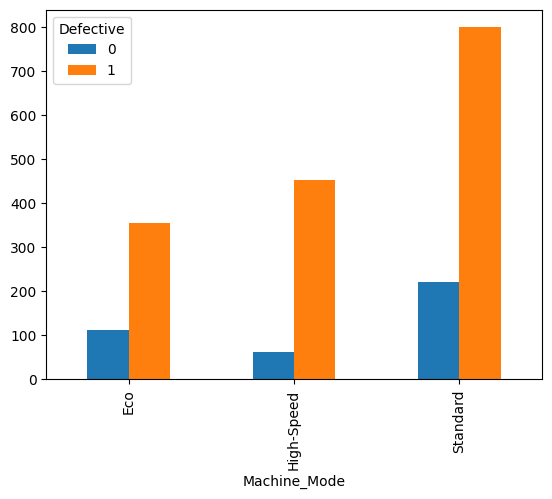

In [356]:
pd.crosstab(df['Machine_Mode'],df['Defective']).plot(kind='bar')

<Axes: xlabel='Maintenance_Level'>

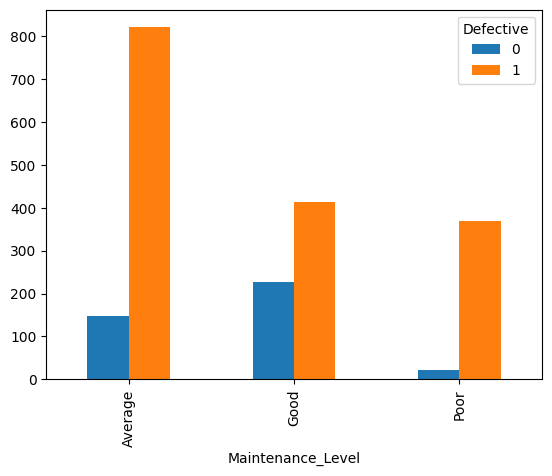

In [357]:
pd.crosstab(df['Maintenance_Level'],df['Defective']).plot(kind='bar')

<Axes: xlabel='Shift_Type'>

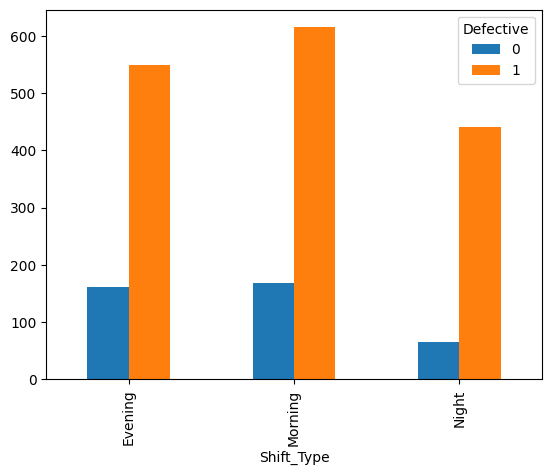

In [358]:
pd.crosstab(df['Shift_Type'],df['Defective']).plot(kind='bar')

In [359]:
new_sub = subdf.drop(["Humidity","Voltage","Current"],axis='columns')
new_sub.head()

,RPM,Vibration,Pressure,Load,Operating_Hours,Machine_Mode,Maintenance_Level,Shift_Type
0,1660,5.17,88.80,51.93,937,High-Speed,Average,Morning
1,4572,0.61,32.04,31.48,9329,Standard,Poor,Evening
2,3892,4.68,113.85,72.09,5946,High-Speed,Average,Evening
3,1266,4.54,38.12,60.90,8563,Standard,Poor,Night
4,4244,4.53,82.28,16.97,2469,Eco,Average,Morning


In [360]:
merged = pd.concat([new_sub,machine_mode_dummies,Maintenance_dummies],axis='columns')
merged.head()

,RPM,Vibration,Pressure,Load,Operating_Hours,Machine_Mode,Maintenance_Level,Shift_Type,Machine_Mode_Eco,Machine_Mode_High-Speed,Machine_Mode_Standard,Maintenance_Level_Average,Maintenance_Level_Good,Maintenance_Level_Poor
0,1660,5.17,88.80,51.93,937,High-Speed,Average,Morning,False,True,False,True,False,False
1,4572,0.61,32.04,31.48,9329,Standard,Poor,Evening,False,False,True,False,False,True
2,3892,4.68,113.85,72.09,5946,High-Speed,Average,Evening,False,True,False,True,False,False
3,1266,4.54,38.12,60.90,8563,Standard,Poor,Night,False,False,True,False,False,True
4,4244,4.53,82.28,16.97,2469,Eco,Average,Morning,True,False,False,True,False,False


In [368]:
final = merged.drop(["Machine_Mode","Maintenance_Level","Shift_Type"],axis='columns')
final.head()

,RPM,Vibration,Pressure,Load,Operating_Hours,Machine_Mode_Eco,Machine_Mode_High-Speed,Machine_Mode_Standard,Maintenance_Level_Average,Maintenance_Level_Good,Maintenance_Level_Poor
0,1660,5.17,88.80,51.93,937,False,True,False,True,False,False
1,4572,0.61,32.04,31.48,9329,False,False,True,False,False,True
2,3892,4.68,113.85,72.09,5946,False,True,False,True,False,False
3,1266,4.54,38.12,60.90,8563,False,False,True,False,False,True
4,4244,4.53,82.28,16.97,2469,True,False,False,True,False,False


In [369]:
y = df['Defective']
y

,Defective
0,1
1,1
2,1
3,1
4,1
...,...
1995,0
1996,1
1997,1
1998,1


In [370]:
x_train,x_test,y_train,y_test = train_test_split(final,y,test_size=0.2)

In [371]:
x_train.head()

,RPM,Vibration,Pressure,Load,Operating_Hours,Machine_Mode_Eco,Machine_Mode_High-Speed,Machine_Mode_Standard,Maintenance_Level_Average,Maintenance_Level_Good,Maintenance_Level_Poor
1900,4159,6.74,56.15,13.13,7322,False,False,True,True,False,False
1812,3185,7.24,109.10,34.50,5858,True,False,False,True,False,False
1658,4402,3.69,62.69,94.98,6055,False,True,False,False,False,True
1126,3970,5.29,63.62,13.80,8755,True,False,False,False,False,True
1775,3510,6.80,45.23,54.95,2202,False,False,True,False,True,False


In [372]:
y_train

,Defective
1900,1
1812,1
1658,1
1126,1
1775,1
...,...
1933,1
1416,1
456,1
1621,0


In [373]:
logistic = linear_model.LogisticRegression(max_iter=100000)

In [374]:
logistic.fit(x_train,y_train)

LogisticRegression(max_iter=100000)

In [375]:
logistic.predict(x_test)

array([1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,

In [376]:
logistic.score(x_test,y_test)

0.8775